In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
from scipy.stats import chi2_contingency

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

user = pd.read_csv('../../data/processed/01_user_profile_preprocessed_v2.csv', encoding='utf-8-sig')
event = pd.read_csv('../../data/processed/02_event_log_preprocessed_v2.csv', encoding='utf-8-sig')

def cramers_v(chi2_stat, n, k=2):
    """Cramér's V 효과크기. k = min(행, 열) — 2열 검정은 기본값 사용."""
    v = round(np.sqrt(chi2_stat / (n * (k - 1))), 3)
    if v < 0.10:
        level = '매우 약함'
    elif v < 0.20:
        level = '약함'
    elif v < 0.40:
        level = '보통'
    else:
        level = '강함'
    return v, level

def get_d30_retention(user_ids, app_launch_df, user_df):
    total = len(user_ids)
    d30_users = app_launch_df[
        (app_launch_df['user_id'].isin(user_ids)) &
        (app_launch_df['days_since_signup'] == 30)
    ]['user_id'].nunique()
    return total, d30_users, round(d30_users / total * 100, 1)

print("함수 로드 완료!")

함수 로드 완료!


In [3]:
user['signup_date'] = pd.to_datetime(user['signup_date'])
event['event_time'] = pd.to_datetime(event['event_time'])
event['event_date'] = pd.to_datetime(event['event_date'])

In [4]:
# 로그 장애 기간 제외
event_clean = event[event['is_log_issue_period'] == False]

In [5]:
# D30 계산용 세팅
event_with_signup = event_clean.merge(
    user[['user_id', 'signup_date']],
    on='user_id', how='left'
)
event_with_signup['days_since_signup'] = (
    event_with_signup['event_date'] - 
    event_with_signup['signup_date']
).dt.days

app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

print("로드 완료!")
print(f"전체 이벤트: {len(event_clean):,}건")

로드 완료!
전체 이벤트: 1,736,400건


In [6]:
user.head()

,user_id,signup_date,signup_channel,device,notification_agreed,notification_changed_date,signup_day,signup_month,signup_weekday,first_event_time,...,onboarding_completed_time,onboarding_elapsed_hours,app_launch_to_onboarding_hours,is_onboarding_completed,event_count_total,avg_events_per_session,is_signup_log_issue_period,is_no_event_user,is_notification_changed,is_first_event_before_signup
0,U0000001,2025-01-25,오가닉,iOS,True,NaN,2025-01-25,2025-01,토,2025-01-25 07:25:45,...,2025-01-25 07:26:15,7.437500,0.008333,True,515,2.07,False,False,False,False
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05,화,2025-05-06 16:23:12,...,NaN,NaN,NaN,False,55,2.62,False,False,True,False
2,U0000003,2025-05-14,오가닉,iOS,False,NaN,2025-05-14,2025-05,수,2025-05-14 11:09:58,...,NaN,NaN,NaN,False,3,1.50,False,False,False,False
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN,2025-02-23,2025-02,일,2025-02-23 07:15:35,...,NaN,NaN,NaN,False,89,1.79,False,False,False,False
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN,2025-02-18,2025-02,화,2025-02-18 12:50:01,...,2025-02-18 12:53:07,12.885278,0.008333,True,442,1.85,False,False,False,False


In [7]:
event.head()

,user_id,event_time,event_type,session_id,notification_type,is_event_type_missing,event_type_display,is_notification_event,is_session_id_missing,is_session_missing_expected,is_session_missing_unexpected,notification_type_display,event_date,event_month,event_weekday,event_hour,is_log_issue_period
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,False,앱실행,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,False,온보딩_완료,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,False,챌린지_탐색,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,False,챌린지참여,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,False,알림수신,True,True,True,False,광고성,2025-01-25,2025-01,토,20,False


통계량이 크다 
→ 관측값과 기댓값 차이가 크다
→ 귀무가설이 맞을 가능성이 낮다
→ p-value가 작아진다

통계량이 작다
→ 관측값과 기댓값 차이가 작다
→ 귀무가설이 맞을 가능성이 높다
→ p-value가 커진다

### 1. 가설설정
- 귀무가설(H0): 기능 경험 여부에 따라 D30 리텐션에 차이가 없다
- 대립가설(H1): 기능 경험 여부에 따라 D30 리텐션에 차이가 있다

- 유의수준: α = 0.05
- → p-value < 0.05 이면 귀무가설 기각 (차이 있음)

**검정 방법 선택 이유**
- 기능 경험 여부 → 범주형 (경험 / 미경험)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 두 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

In [8]:
activity_types = {
    '수면기록': '수면기록',
    '운동기록': '운동기록',
    '식단기록': '식단기록',
    '마음챙김': '마음챙김',
    '챌린지참여': '챌린지참여'
}

all_users = set(user['user_id'])

for name, event_type in activity_types.items():
    exp_users = set(event_clean[event_clean['event_type'] == event_type]['user_id'])
    non_users = all_users - exp_users

    t1, d1, r1 = get_d30_retention(exp_users, app_launch, user)
    t2, d2, r2 = get_d30_retention(non_users, app_launch, user)

    table = [[d1, t1-d1], [d2, t2-d2]]
    chi2, p, dof, expected = chi2_contingency(table)
    v, v_level = cramers_v(chi2, t1 + t2)

    df = pd.DataFrame({
        '구분': [f'{name} 경험', f'{name} 미경험'],
        '전체유저수': [t1, t2],
        'D30 유저수': [d1, d2],
        'D30 리텐션(%)': [r1, r2],
    })

    stat_df = pd.DataFrame({
        '카이제곱 통계량': [round(chi2, 4)],
        '자유도': [dof],
        'p-value': [f'{p:.2e}'],
        "Cramér's V": [v],
        '효과크기': [v_level],
        '결론': ['유의미 O' if p < 0.05 else '유의미 X']
    })

    print(f"\n=== {name} ===")
    display(df)
    display(stat_df)
    print("-" * 50)


=== 수면기록 ===


,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,수면기록 경험,11432,2943,25.7
1,수면기록 미경험,1068,0,0.0


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,358.1779,1,7.02e-80,0.169,약함,유의미 O


--------------------------------------------------

=== 운동기록 ===


,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,운동기록 경험,10374,2943,28.4
1,운동기록 미경험,2126,0,0.0


...

,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,606.454,1,6.61e-134,0.22,보통,유의미 O


--------------------------------------------------

=== 챌린지참여 ===


,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,챌린지참여 경험,9321,2930,31.4
1,챌린지참여 미경험,3179,13,0.4


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,1265.893,1,2.92e-277,0.318,보통,유의미 O


--------------------------------------------------


In [9]:
for name, event_type in activity_types.items():
    exp_users = set(event_clean[event_clean['event_type'] == event_type]['user_id'])
    non_users = all_users - exp_users

    t1, d1, r1 = get_d30_retention(exp_users, app_launch, user)
    t2, d2, r2 = get_d30_retention(non_users, app_launch, user)

    table = [[d1, t1-d1], [d2, t2-d2]]
    chi2, p, dof, expected = chi2_contingency(table)
    v, v_level = cramers_v(chi2, t1 + t2)

    df = pd.DataFrame({
        '구분': [f'{name} 경험', f'{name} 미경험'],
        '전체유저수': [t1, t2],
        'D30 유저수': [d1, d2],
        'D30 리텐션(%)': [r1, r2],
    })

    stat_df = pd.DataFrame({
        '카이제곱 통계량': [round(chi2, 4)],
        '자유도': [dof],
        'p-value': [f'{p:.2e}'],
        "Cramér's V": [v],
        '효과크기': [v_level],
        '결론': ['유의미 O' if p < 0.05 else '유의미 X']
    })

    print(f"\n=== {name} ===")
    display(df)
    display(stat_df)
    print("-" * 50)


=== 수면기록 ===


,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,수면기록 경험,11432,2943,25.7
1,수면기록 미경험,1068,0,0.0


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,358.1779,1,7.02e-80,0.169,약함,유의미 O


--------------------------------------------------

=== 운동기록 ===


,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,운동기록 경험,10374,2943,28.4
1,운동기록 미경험,2126,0,0.0


...

,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,606.454,1,6.61e-134,0.22,보통,유의미 O


--------------------------------------------------

=== 챌린지참여 ===


,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,챌린지참여 경험,9321,2930,31.4
1,챌린지참여 미경험,3179,13,0.4


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,1265.893,1,2.92e-277,0.318,보통,유의미 O


--------------------------------------------------


**Cramér's V 효과크기**

| 기능 | Cramér's V | 연관 강도 |
|------|-----------|---------|
| 수면기록 | 0.169 | 약함 |
| 운동기록 | 0.251 | 보통 |
| 식단기록 | 0.262 | 보통 |
| 마음챙김 | 0.220 | 보통 |
| 챌린지참여 | 0.318 | 보통 |

챌린지참여(V = 0.318)가 단일 기능 중 가장 강한 연관성

**결론**

카이제곱 검정 결과 p-value < 0.05이므로 귀무가설을 기각한다.

모든 기능에서 경험 유저의 D30이 미경험 유저보다 유의미하게 높다.
기능 경험 여부는 D30 리텐션에 유의미한 영향을 미친다.

**한계점**

미경험 유저의 D30이 대부분 0%라 경험/미경험 이분법에 크게 의존하는 결과로,
다른 혼재 변수(가입 기간, 앱 버전 등)가 있을 수 있음

### 2. 가설 설정
귀무가설(H0): 수면기록 이후 다른 기능으로 확장한 여부에 따라
              D30 리텐션에 차이가 없다

대립가설(H1): 수면기록 이후 다른 기능으로 확장한 여부에 따라
              D30 리텐션에 차이가 있다

유의수준: α = 0.05

**검정 방법 선택 이유**
- 확장 여부 → 범주형 (확장형 / 미확장형)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 두 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

확장형:
수면기록 O + 운동기록/식단기록/마음챙김/챌린지 중 하나라도 O
→ 수면기록을 시작으로 다른 기능까지 쓴 유저

미확장형:
수면기록 O + 다른 기능 X
→ 수면기록만 쓰고 다른 기능은 안 쓴 유저

In [10]:
# 수면기록 경험 유저
sleep_users = set(event_clean[event_clean['event_type'] == '수면기록']['user_id'])

# 다른 기능도 쓴 유저 (확장형)
other_features = ['운동기록', '식단기록', '마음챙김', '챌린지참여']
expanded_users = set(
    event_clean[
        (event_clean['user_id'].isin(sleep_users)) &
        (event_clean['event_type'].isin(other_features))
    ]['user_id']
)

# 수면기록만 한 유저 (미확장형)
not_expanded_users = sleep_users - expanded_users

print(f"수면기록 경험 유저: {len(sleep_users):,}명")
print(f"확장형 유저: {len(expanded_users):,}명")
print(f"미확장형 유저: {len(not_expanded_users):,}명")

수면기록 경험 유저: 11,432명
확장형 유저: 11,249명
미확장형 유저: 183명


미확장형이 183명으로 샘플이 너무 적어서 통계검정 결과가 나와도 신뢰가....

In [11]:
t1, d1, r1 = get_d30_retention(expanded_users, app_launch, user)
t2, d2, r2 = get_d30_retention(not_expanded_users, app_launch, user)

table = [[d1, t1-d1], [d2, t2-d2]]
chi2, p, dof, expected = chi2_contingency(table)
v, v_level = cramers_v(chi2, t1 + t2)

df = pd.DataFrame({
    '구분': ['확장형', '미확장형'],
    '전체유저수': [t1, t2],
    'D30 유저수': [d1, d2],
    'D30 리텐션(%)': [r1, r2],
})

stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '유의미 X']
})

display(df)
display(stat_df)

,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,확장형,11249,2943,26.2
1,미확장형,183,0,0.0


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,63.1139,1,1.95e-15,0.074,매우 약함,유의미 O


**Cramér's V 효과크기**

Cramér's V = **0.074** → 연관성 매우 약함

(χ² = 63.11, n = 11,432)

**결론**

수면기록 이후 다른 기능으로 확장한 유저의 D30이 26.2%,

미확장형 유저는 0.0%로 통계적으로 유의미한 차이가 있다.

한계점

미확장형 유저가 183명으로 샘플이 적어

결과 해석 시 주의 필요

### 3. 가설 설정
- 귀무가설(H0): 가입경로별 D30 리텐션에 차이가 없다
- 대립가설(H1): 가입경로별 D30 리텐션에 차이가 있다
- 유의수준: α = 0.05

**검정 방법 선택 이유**
- 가입경로 → 범주형 (오가닉 / 퍼포먼스광고)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 두 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

In [12]:
organic_users = set(user[user['signup_channel'] == '오가닉']['user_id'])
ad_users = set(user[user['signup_channel'] == '퍼포먼스광고']['user_id'])

t1, d1, r1 = get_d30_retention(organic_users, app_launch, user)
t2, d2, r2 = get_d30_retention(ad_users, app_launch, user)

table = [[d1, t1-d1], [d2, t2-d2]]
chi2, p, dof, expected = chi2_contingency(table)
v, v_level = cramers_v(chi2, t1 + t2)

df = pd.DataFrame({
    '구분': ['오가닉', '퍼포먼스광고'],
    '전체유저수': [t1, t2],
    'D30 유저수': [d1, d2],
    'D30 리텐션(%)': [r1, r2],
})

stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '유의미 X']
})

display(df)
display(stat_df)

,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,오가닉,5511,1306,23.7
1,퍼포먼스광고,6852,1604,23.4


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,0.126,1,7.23e-01,0.003,매우 약함,유의미 X


p-value = 0.723 > 0.05 → 귀무가설을 기각하지 못한다.

**Cramér's V 효과크기**

Cramér's V = **0.003** → 연관성 매우 약함

(χ² = 0.13, n = 12,363)

**결론**

오가닉과 퍼포먼스광고 유저 간 D30 리텐션 차이(23.7% vs 23.4%)는

통계적으로 유의미하지 않다.

즉, 가입경로는 D30 리텐션에 영향을 미치지 않는다.

**추가 인사이트**

"광고로 데려온 유저가 오가닉 유저보다 리텐션이 낮을 것이다"

→ 이 가설이 틀렸음을 데이터로 증명

**한계점**

오가닉/퍼포먼스광고 두 채널만 분석하였으며, 세부 광고 유형(SNS, 검색광고 등) 미구분으로
채널 세분화 시 차이가 있을 수 있음

### 4. 가설 설정
- 귀무가설(H0): 기기별로 D30 리텐션에 차이가 없다
- 대립가설(H1): 기기별로 D30 리텐션에 차이가 있다
- 유의수준: α = 0.05

**검정 방법 선택 이유**
- 기기 → 범주형 (iOS / Android)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 두 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

In [13]:
ios_users = set(user[user['device'] == 'iOS']['user_id'])
android_users = set(user[user['device'] == 'Android']['user_id'])

t1, d1, r1 = get_d30_retention(ios_users, app_launch, user)
t2, d2, r2 = get_d30_retention(android_users, app_launch, user)

table = [[d1, t1-d1], [d2, t2-d2]]
chi2, p, dof, expected = chi2_contingency(table)
v, v_level = cramers_v(chi2, t1 + t2)

df = pd.DataFrame({
    '구분': ['iOS', 'Android'],
    '전체유저수': [t1, t2],
    'D30 유저수': [d1, d2],
    'D30 리텐션(%)': [r1, r2],
})

stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '유의미 X']
})

display(df)
display(stat_df)

,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,iOS,7175,1678,23.4
1,Android,5204,1234,23.7


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,0.1603,1,6.89e-01,0.004,매우 약함,유의미 X


p-value = 0.689 > 0.05 → 귀무가설 기각하지 못한다.

**Cramér's V 효과크기**

Cramér's V = **0.004** → 연관성 매우 약함

(χ² = 0.16, n = 12,379)

**결론**

iOS와 Android 유저 간 D30 리텐션 차이(23.4% vs 23.7%)는

통계적으로 유의미하지 않다.

즉, 기기 종류는 D30 리텐션에 영향을 미치지 않는다.

**한계점**

iOS/Android 구분만 분석하였으며, OS 버전이나 기기 성능별 차이는 분석 범위에서 제외

### 지금까지 통계검정한걸 바탕으로 나온 인사이트
가입경로(오가닉 vs 광고)와 기기(iOS vs Android) 모두

D30 리텐션에 유의미한 영향을 미치지 않는다.

즉, 리텐션 하락 원인은 유입 채널이나 플랫폼이 아니라

앱 내부 경험(기능 사용, 챌린지 참여)에 있다.

### 5. 가설 설정
- 귀무가설(H0): 월별 코호트에 따라 D30 리텐션에 차이가 없다
- 대립가설(H1): 월별 코호트에 따라 D30 리텐션에 차이가 있다
- 유의수준: α = 0.05

**검정 방법 선택 이유**
- 가입월 → 범주형 (2025-01 ~ 2025-05, 5그룹)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 다중 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

In [14]:
user['signup_month'] = pd.to_datetime(user['signup_date']).dt.to_period('M').astype(str)

result = []
contingency = []

for month in sorted(user['signup_month'].unique()):
    month_users = set(user[user['signup_month'] == month]['user_id'])
    t, d, r = get_d30_retention(month_users, app_launch, user)
    result.append({'코호트': month, '전체유저수': t, 'D30유저수': d, 'D30리텐션(%)': r})
    contingency.append([d, t - d])

chi2, p, dof, expected = chi2_contingency(contingency)
n = sum(row[0] + row[1] for row in contingency)
v, v_level = cramers_v(chi2, n)

df = pd.DataFrame(result)
stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '유의미 X']
})

display(df)
display(stat_df)

,코호트,전체유저수,D30유저수,D30리텐션(%)
0,2025-01,2124,480,22.6
1,2025-02,4384,1178,26.9
2,2025-03,2122,488,23.0
3,2025-04,2082,432,20.7
4,2025-05,1788,365,20.4


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,47.1209,4,1.44e-09,0.061,매우 약함,유의미 O


p-value = 1.44e-09 < 0.05 → 귀무가설 기각이 가능하다.

**Cramér's V 효과크기**

Cramér's V = **0.061** → 연관성 매우 약함

(χ² = 47.12, n = 12,500, df = 4)

통계적으로 유의미하나 실용적 효과 크기는 작음

**결론**

월별 코호트에 따라 D30 리텐션에 통계적으로 유의미한 차이가 있다.

2월 코호트가 26.9%로 가장 높고, 4~5월 코호트는 20%대로 하락 추세를 보인다.

### 한계점
3월 코호트는 로그 수집 장애(3/10~14) 영향으로

실제보다 낮게 측정되었을 가능성 있음

### 6. 가설 설정
- 귀무가설(H0): 알림 동의 여부에 따라 D30 리텐션에 차이가 없다
- 대립가설(H1): 알림 동의 여부에 따라 D30 리텐션에 차이가 있다
- 유의수준: α = 0.05

**검정 방법 선택 이유**
- 알림 동의 여부 → 범주형 (동의 / 미동의, Unknown 116명 제외)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 두 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

In [15]:
print(user['notification_agreed'].value_counts())
print(user['notification_agreed'].dtype)

notification_agreed
True       7984
False      4400
Unknown     116
Name: count, dtype: int64
str


Unknown 제외 하고 확인 했음.

In [16]:
agreed_users = set(user[user['notification_agreed'] == 'True']['user_id'])
not_agreed_users = set(user[user['notification_agreed'] == 'False']['user_id'])

print(f"알림 동의: {len(agreed_users):,}명")
print(f"알림 미동의: {len(not_agreed_users):,}명")

t1, d1, r1 = get_d30_retention(agreed_users, app_launch, user)
t2, d2, r2 = get_d30_retention(not_agreed_users, app_launch, user)

알림 동의: 7,984명
알림 미동의: 4,400명


In [17]:
agreed_users = set(user[user['notification_agreed'] == 'True']['user_id'])
not_agreed_users = set(user[user['notification_agreed'] == 'False']['user_id'])

t1, d1, r1 = get_d30_retention(agreed_users, app_launch, user)
t2, d2, r2 = get_d30_retention(not_agreed_users, app_launch, user)

table = [[d1, t1-d1], [d2, t2-d2]]
chi2, p, dof, expected = chi2_contingency(table)
v, v_level = cramers_v(chi2, t1 + t2)

df = pd.DataFrame({
    '구분': ['알림 동의', '알림 미동의'],
    '전체유저수': [t1, t2],
    'D30 유저수': [d1, d2],
    'D30 리텐션(%)': [r1, r2],
})

stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '귀무가설 기각 못함 X']
})

display(df)
display(stat_df)

,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,알림 동의,7984,1836,23.0
1,알림 미동의,4400,1080,24.5


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,3.6975,1,5.45e-02,0.017,매우 약함,귀무가설 기각 못함 X


p-value = 0.0545 > 0.05 → 귀무가설 기각하지 못함 (유의수준에 매우 근접)

**Cramér's V 효과크기**

Cramér's V = **0.017** → 연관성 매우 약함

(χ² = 3.70, n = 12,384)

**결론**

알림 동의 여부에 따른 D30 리텐션 차이(23.0% vs 24.5%)는
통계적으로 유의미하지 않다.

즉, 알림 동의 여부는 D30 리텐션에 영향을 미치지 않는다.

알림 미동의 유저(24.5%)가 오히려 동의 유저(23.0%)보다 D30이 약간 높으나, p = 0.055로 통계적으로 유의미하지 않음

한계점:
p-value가 0.055로 유의수준 0.05에 매우 근접해

유의수준을 0.1로 설정했다면 유의미했을 수 있음.

### 7. 가설 설정
- 귀무가설(H0): 온보딩 완료 후 첫 활동 여부에 따라 D30 리텐션에 차이가 없다
- 대립가설(H1): 온보딩 완료 후 첫 활동 여부에 따라 D30 리텐션에 차이가 있다
- 유의수준: α = 0.05

**검정 방법 선택 이유**
- 온보딩+첫활동 여부 → 범주형 (완료+활동O / 완료+활동X / 미완료, 3그룹)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 다중 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

In [18]:
activity_types = ['수면기록', '운동기록', '식단기록', '마음챙김', '챌린지참여']

completed_ids = set(user[user['is_onboarding_completed'] == True]['user_id'])

first_activity_ids = set(
    event_clean[
        (event_clean['user_id'].isin(completed_ids)) &
        (event_clean['event_type'].isin(activity_types))
    ]['user_id']
)

completed_with_activity = first_activity_ids
completed_no_activity = completed_ids - first_activity_ids
not_completed = set(user['user_id']) - completed_ids

t1, d1, r1 = get_d30_retention(completed_with_activity, app_launch, user)
t2, d2, r2 = get_d30_retention(completed_no_activity, app_launch, user)
t3, d3, r3 = get_d30_retention(not_completed, app_launch, user)

table = [[d1, t1-d1], [d2, t2-d2], [d3, t3-d3]]
chi2, p, dof, expected = chi2_contingency(table)
v, v_level = cramers_v(chi2, t1 + t2 + t3)

df = pd.DataFrame({
    '구분': ['온보딩완료+첫활동O', '온보딩완료+첫활동X', '온보딩미완료'],
    '전체유저수': [t1, t2, t3],
    'D30 유저수': [d1, d2, d3],
    'D30 리텐션(%)': [r1, r2, r3],
})

stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '귀무가설 기각 못함 X']
})

display(df)
display(stat_df)

,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,온보딩완료+첫활동O,5658,1621,28.6
1,온보딩완료+첫활동X,61,0,0.0
2,온보딩미완료,6781,1322,19.5


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,162.4605,2,5.27e-36,0.114,약함,유의미 O


p-value = 5.27e-36 < 0.05 → 귀무가설 기각 가능

**Cramér's V 효과크기**

Cramér's V = **0.114** → 연관성 약함

(χ² = 162.46, n = 12,500, df = 2)

**결론**

온보딩 완료 후 첫 활동 여부에 따라 D30 리텐션에 통계적으로 유의미한 차이가 있다.

온보딩 완료 후 첫 활동을 한 유저(28.6%)가 미완료 유저(19.5%)보다 높으며,

온보딩 완료 후 첫 활동을 하지 않은 유저는 D30이 0.0%다.

한계점: 온보딩완료+첫활동X 61명으로 샘플이 적어 해석 주의 필요

### 8. 가설 설정
- 귀무가설(H0): 온보딩+챌린지 조합에 따라 D30 리텐션에 차이가 없다
- 대립가설(H1): 온보딩+챌린지 조합에 따라 D30 리텐션에 차이가 있다
- 유의수준: α = 0.05

**검정 방법 선택 이유**
- 온보딩+챌린지 조합 → 범주형 (4그룹: 완료+O/X, 미완료+O/X)
- D30 리텐션 여부 → 범주형 (복귀 / 미복귀)
- 다중 범주형 변수 간 독립성 검정 → 카이제곱 검정 사용

In [19]:
challenge_ids = set(event_clean[event_clean['event_type'] == '챌린지참여']['user_id'])
completed_ids = set(user[user['is_onboarding_completed'] == True]['user_id'])
all_user_ids = set(user['user_id'])

group1 = completed_ids & challenge_ids
group2 = completed_ids - challenge_ids
group3 = (all_user_ids - completed_ids) & challenge_ids
group4 = (all_user_ids - completed_ids) - challenge_ids

t1, d1, r1 = get_d30_retention(group1, app_launch, user)
t2, d2, r2 = get_d30_retention(group2, app_launch, user)
t3, d3, r3 = get_d30_retention(group3, app_launch, user)
t4, d4, r4 = get_d30_retention(group4, app_launch, user)

table = [[d1, t1-d1], [d2, t2-d2], [d3, t3-d3], [d4, t4-d4]]
chi2, p, dof, expected = chi2_contingency(table)
v, v_level = cramers_v(chi2, t1 + t2 + t3 + t4)

df = pd.DataFrame({
    '구분': ['온보딩완료+챌린지O', '온보딩완료+챌린지X', '온보딩미완료+챌린지O', '온보딩미완료+챌린지X'],
    '전체유저수': [t1, t2, t3, t4],
    'D30 유저수': [d1, d2, d3, d4],
    'D30 리텐션(%)': [r1, r2, r3, r4],
})

stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '귀무가설 기각 못함 X']
})

display(df)
display(stat_df)

,구분,전체유저수,D30 유저수,D30 리텐션(%)
0,온보딩완료+챌린지O,4928,1615,32.8
1,온보딩완료+챌린지X,791,6,0.8
2,온보딩미완료+챌린지O,4393,1315,29.9
3,온보딩미완료+챌린지X,2388,7,0.3


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,1278.0791,3,8.40e-277,0.32,보통,유의미 O


p-value = 8.40e-277 < 0.05 → 귀무가설 기각가능

**Cramér's V 효과크기**

Cramér's V = **0.320** → 연관성 보통

(χ² = 1278.08, n = 12,500, df = 3)

**결론**

챌린지 참여 여부가 온보딩 완료 여부보다 D30에 더 결정적이다.

온보딩 미완료여도 챌린지 참여 시 D30 29.9%,

온보딩 완료해도 챌린지 미참여 시 D30 0.8%

온보딩+챌린지 조합에 따라 D30 리텐션에 통계적으로 유의미한 차이가 있다.

챌린지 참여가 D30 리텐션의 핵심 드라이버임이 통계적으로 검증완료.

**한계점**

온보딩 완료와 챌린지 참여 간 인과관계 검증 불가
(챌린지 참여가 온보딩 완료 이후에 이루어진 행동일 수 있어 역인과 가능성 존재)

---

## 종합 요약

### Cramér's V 해석 기준
| V 값 | 연관 강도 |
|------|---------|
| < 0.10 | 매우 약함 |
| 0.10 ~ 0.20 | 약함 |
| 0.20 ~ 0.40 | 보통 |
| ≥ 0.40 | 강함 |

### 전체 검정 결과

| # | 검정 항목 | p-value | 유의미 | Cramér's V | 연관 강도 |
|---|---------|---------|:------:|-----------|:-------:|
| 1 | 수면기록 경험 → D30 | 7.02e-80 | O | 0.169 | 약함 |
| 1 | 운동기록 경험 → D30 | 3.15e-173 | O | 0.251 | 보통 |
| 1 | 식단기록 경험 → D30 | 1.02e-188 | O | 0.262 | 보통 |
| 1 | 마음챙김 경험 → D30 | 6.61e-134 | O | 0.220 | 보통 |
| 1 | 챌린지참여 경험 → D30 | 2.92e-277 | O | 0.318 | 보통 |
| 2 | 수면기록 확장 여부 → D30 | 1.95e-15 | O | 0.074 | 매우 약함 |
| 3 | 가입경로(오가닉/광고) → D30 | 7.23e-01 | X | 0.003 | 매우 약함 |
| 4 | 기기(iOS/Android) → D30 | 6.89e-01 | X | 0.004 | 매우 약함 |
| 5 | 월별 코호트 → D30 | 1.44e-09 | O | 0.061 | 매우 약함 |
| 6 | 알림 동의 여부 → D30 | 5.45e-02 | X | 0.017 | 매우 약함 |
| 7 | 온보딩 + 첫 활동 여부 → D30 | 5.27e-36 | O | 0.114 | 약함 |
| 8 | 온보딩 + 챌린지 조합 → D30 | 8.40e-277 | O | 0.320 | 보통 |

### 핵심 인사이트

**D30 리텐션에 실질적 영향을 미치는 요인 (V ≥ 0.2)**

1. **온보딩 + 챌린지 조합** (V = 0.320, 보통)
2. **챌린지 참여** (V = 0.318, 보통) — 단일 기능 중 최강
3. **식단기록 경험** (V = 0.262, 보통)
4. **운동기록 경험** (V = 0.251, 보통)
5. **마음챙김 경험** (V = 0.220, 보통)

**통계적으로 유의미하나 효과 크기가 작은 요인**

- 수면기록 경험 (V = 0.169, 약함)
- 온보딩 + 첫 활동 여부 (V = 0.114, 약함)

**D30 리텐션에 영향 없는 요인**

- 가입경로(오가닉 vs 광고): V = 0.003 → 사실상 차이 없음
- 기기 종류(iOS vs Android): V = 0.004 → 사실상 차이 없음
- 알림 동의 여부: V = 0.017, p = 0.055 → 통계적으로도 비유의미

### 결론

> D30 리텐션은 유입 채널이나 기기가 아닌 **앱 내 행동**에 의해 결정된다.
> 챌린지 참여와 식단/운동 기록이 리텐션과 가장 강한 연관성을 보이며,
> 온보딩 완료 후 기능을 실제로 사용하는 것이 이탈 방지의 핵심이다.

### 가설설정(추가 1개)
- 귀무가설: 기능 사용 개수에 따라 D30 리텐션에 차이가 없다
- 대립가설: 기능 사용 개수에 따라 D30 리텐션에 차이가 있다
- 유의수준: α = 0.05
- 검정방법: 카이제곱 검정 (기능 사용 개수(범주형) × D30 복귀 여부(범주형))

In [22]:
activity_types = ['수면기록', '운동기록', '식단기록', '마음챙김', '챌린지참여']

# 유저별 기능 사용 개수 한번에 계산
feature_events = event_clean[event_clean['event_type'].isin(activity_types)]
user_feature_count = feature_events.groupby('user_id')['event_type'].nunique()

user['기능사용개수'] = user['user_id'].map(user_feature_count).fillna(0).astype(int)

print("=== 기능 사용 개수별 유저 수 ===")
print(user['기능사용개수'].value_counts().sort_index())

=== 기능 사용 개수별 유저 수 ===
기능사용개수
0     283
1     473
2     808
3    1232
4    2166
5    7538
Name: count, dtype: int64


In [23]:
result = []
contingency = []

for count in range(6):
    count_users = set(user[user['기능사용개수'] == count]['user_id'])
    t, d, r = get_d30_retention(count_users, app_launch, user)
    result.append({'기능사용개수': f'{count}개', '유저수': t, 'D30유저수': d, 'D30리텐션(%)': r})
    contingency.append([d, t - d])

chi2, p, dof, expected = chi2_contingency(contingency)
n = sum([r['유저수'] for r in result])
v, v_level = cramers_v(chi2, n, 2)

df = pd.DataFrame(result)
stat_df = pd.DataFrame({
    '카이제곱 통계량': [round(chi2, 4)],
    '자유도': [dof],
    'p-value': [f'{p:.2e}'],
    "Cramér's V": [v],
    '효과크기': [v_level],
    '결론': ['유의미 O' if p < 0.05 else '귀무가설 기각 못함 X']
})

display(df)
display(stat_df)

,기능사용개수,유저수,D30유저수,D30리텐션(%)
0,0개,283,0,0.0
1,1개,473,0,0.0
2,2개,808,0,0.0
3,3개,1232,0,0.0
4,4개,2166,13,0.6
5,5개,7538,2930,38.9


,카이제곱 통계량,자유도,p-value,Cramér's V,효과크기,결론
0,2478.007,5,0.00e+00,0.445,강함,유의미 O


Cramér's V = 0.445 → 강함

5개 기능을 전부 경험한 유저만 D30에 살아남는다

유저가 5개 기능을 모두 사용했는지 여부를 추적하면

이탈 위험 유저를 조기에 감지할 수 있다.

4개 이하 사용 유저 = 이탈 위험군으로 분류 가능

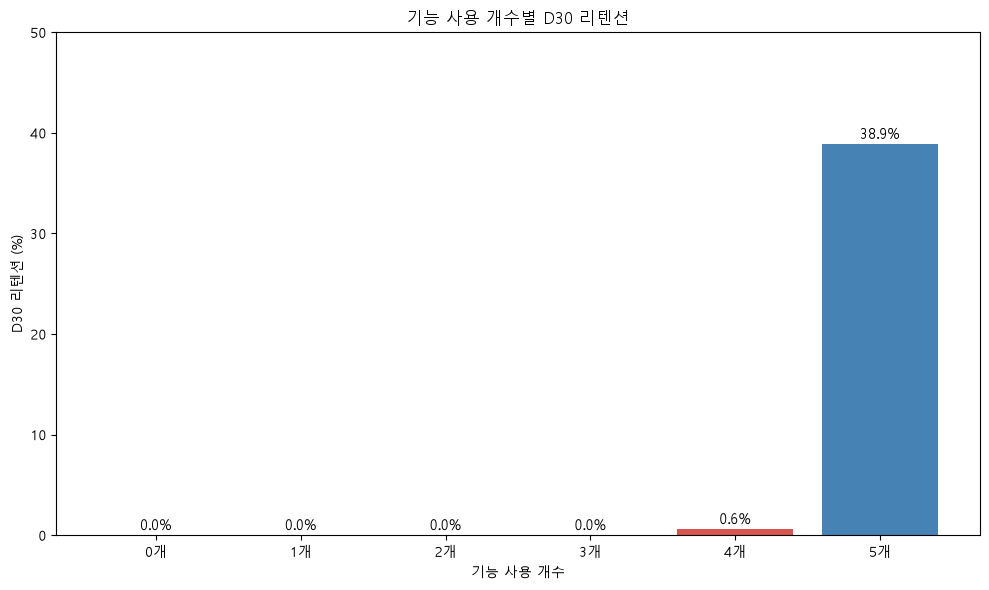

In [24]:
labels = ['0개', '1개', '2개', '3개', '4개', '5개']
values = [0.0, 0.0, 0.0, 0.0, 0.6, 38.9]
colors = ['#d9534f'] * 5 + ['steelblue']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.title('기능 사용 개수별 D30 리텐션')
plt.xlabel('기능 사용 개수')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 50)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

**결론**
기능 사용 개수에 따라 D30 리텐션에 통계적으로 유의미한 차이가 있다.
(p < 0.05, Cramér's V = 0.445 → 강한 연관성)
5개 기능을 전부 경험한 유저의 D30이 38.9%로 압도적으로 높다.
4개 이하 사용 유저는 D30이 0~0.6%에 불과해 이탈 위험군으로 분류 가능하다.

**한계점**
- 인과관계 미검증: 원래 앱에 관심 많은 유저가 기능도 많이 쓰고 D30도 높을 수 있음.
- 인과관계 검증을 위해 특정 기능 사용 유도 A/B 테스트 필요.